# Проект: 
Аналитический отчет для проекта «Карта ДТП»

# Цель: 
Провести исследовательский анализ данных о дорожно-транспортных происшествиях (ДТП) в России. Выявить проблемы качества данных, оценить динамику аварийности и влияние опыта водителей на безопасность дорожного движения.

# Задачи проекта:

* Подготовить датасет к работе, проведя его предобработку: убрать дубликаты и пропуски, проверить корректность числовых и временных значений.
* Анализ временной динамики: исследовать изменение числа ДТП по годам, месяцам и времени суток.
* Сегментация по опыту водителей: сравнить частоту возникновения ДТП среди групп водителей с разным стажем управления транспортным средством.
* Формирование рекомендаций: подготовить выводы для улучшения сбора данных и повышения безопасности на дорогах.

# Описание данных

Данные `Kirovskaya_oblast.csv`, `Moscowskaya_oblast.csv` содержат информацию ДТП:

* `geometry.coordinates` — координаты ДТП;

* `id` — идентификатор ДТП;

*  `properties.tags` — тег происшествия;

*  `properties.light` — освещённость;

*  `properties.point.lat` — широта;

*  `properties.point.long` — долгота;

*  `properties.nearby` — ближайшие объекты;

*  `properties.region` — регион;

*  `properties.scheme` — схема ДТП;

*  `properties.address` — ближайший адрес;

*  `properties.weather` — погода;

*  `properties.category` — категория ДТП;

*  `properties.datetime` — дата и время ДТП;

*  `properties.injured_count` — число пострадавших;

*  `properties.parent_region` — область;

*  `properties.road_conditions` — состояние покрытия;

*  `properties.participants_count` — число участников;

*  `properties.participant_categories` — категории участников.

`Moscowskaya_oblast_participiants.csv`, `Kirovskaya_oblast_participiants.csv` — сведения об участниках ДТП:

* `role` — роль;

* `gender` — пол;

* `violations` — какие правила дорожного движения были нарушены конкретным участником;

* `health_status` — состояние здоровья после  ДТП;

* `years_of_driving_experience` — число лет опыта;

* `id` — идентификатор ДТП.


`Kirovskaya_oblast_vehicles.csv`, `Moscowskaya_oblast_vehicles.csv` — сведения о транспортных средствах:

* `year` — год выпуска;

* `brand` — марка транспортного средства;

* `color` — цвет;

* `model` — модель;

* `category` — категория;

* `id` — идентификатор ДТП.

# Проверка ошибок в данных и их предобработка

In [1]:
!pip install phik
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from phik import phik_matrix

     |████████████████████████████████| 677 kB 1.7 MB/s eta 0:00:01


In [2]:
Kirovskaya_oblast_df = pd.read_csv('/datasets/Kirovskaya_oblast.csv')
Moscowskaya_oblast_df = pd.read_csv("https://code.s3.yandex.net/datasets/Moscowskaya_oblast.csv")

In [3]:
Moscowskaya_oblast_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45618 entries, 0 to 45617
Data columns (total 18 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   geometry.coordinates               45618 non-null  object 
 1   id                                 45618 non-null  int64  
 2   properties.tags                    45618 non-null  object 
 3   properties.light                   45618 non-null  object 
 4   properties.point.lat               45615 non-null  float64
 5   properties.point.long              45615 non-null  float64
 6   properties.nearby                  45618 non-null  object 
 7   properties.region                  45618 non-null  object 
 8   properties.scheme                  44235 non-null  float64
 9   properties.address                 43862 non-null  object 
 10  properties.weather                 45618 non-null  object 
 11  properties.category                45618 non-null  obj

In [4]:
missing_percentage_1 = Moscowskaya_oblast_df.isna().mean() * 100

print(missing_percentage_1)

geometry.coordinates                 0.000000
id                                   0.000000
properties.tags                      0.000000
properties.light                     0.000000
properties.point.lat                 0.006576
properties.point.long                0.006576
properties.nearby                    0.000000
properties.region                    0.000000
properties.scheme                    3.031698
properties.address                   3.849358
properties.weather                   0.000000
properties.category                  0.000000
properties.datetime                  0.000000
properties.injured_count             0.000000
properties.parent_region             0.000000
properties.road_conditions           0.000000
properties.participants_count        0.000000
properties.participant_categories    0.000000
dtype: float64


Датасет содержит 45 618 записей о ДТП. Данные в целом качественные, пропуски минимальны и локализованы в полях «адрес» (3,8 %) и «схема ДТП» (3 %), что составляет менее 4 %, поэтому мы их можем проигнорировать. Тип данных у даты необходимо преобразовать.

In [5]:
Moscowskaya_oblast_df['properties.datetime'] = pd.to_datetime(Moscowskaya_oblast_df['properties.datetime'], errors='coerce')

In [6]:
Kirovskaya_oblast_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14517 entries, 0 to 14516
Data columns (total 18 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   geometry.coordinates               14517 non-null  object 
 1   id                                 14517 non-null  int64  
 2   properties.tags                    14517 non-null  object 
 3   properties.light                   14517 non-null  object 
 4   properties.point.lat               14485 non-null  float64
 5   properties.point.long              14485 non-null  float64
 6   properties.nearby                  14517 non-null  object 
 7   properties.region                  14517 non-null  object 
 8   properties.scheme                  13380 non-null  float64
 9   properties.address                 13843 non-null  object 
 10  properties.weather                 14517 non-null  object 
 11  properties.category                14517 non-null  obj

In [7]:
missing_percentage = Kirovskaya_oblast_df.isna().mean() * 100

print(missing_percentage)

geometry.coordinates                 0.000000
id                                   0.000000
properties.tags                      0.000000
properties.light                     0.000000
properties.point.lat                 0.220431
properties.point.long                0.220431
properties.nearby                    0.000000
properties.region                    0.000000
properties.scheme                    7.832197
properties.address                   4.642833
properties.weather                   0.000000
properties.category                  0.000000
properties.datetime                  0.000000
properties.injured_count             0.000000
properties.parent_region             0.000000
properties.road_conditions           0.000000
properties.participants_count        0.000000
properties.participant_categories    0.000000
dtype: float64


Датасет по Кировской области содержит 14 517 записей о ДТП. Данные достаточно чистые: критических пропусков нет, основные метрики (число пострадавших, участников) заполнены полностью.
Столбец datetime необхоимо будет привести к типу datetime для дальнейшего анализа. 
Наибольший процент пропусков наблюдается в поле scheme (7,8%) и address (4,6%). Пропуски в координатах минимальны (0,22%) и не повлияют на дальнейший анализ.

In [8]:
Kirovskaya_oblast_df['properties.datetime'] = pd.to_datetime(
    Kirovskaya_oblast_df['properties.datetime'], 
    errors='coerce'
)

Для удобства дальнейшего анализа данные по ДТП из двух регионов (Кировской и Московской областей) объединим в один общий датафрейм result_dtp_df.

In [9]:
result_dtp_df = pd.concat([Kirovskaya_oblast_df, Moscowskaya_oblast_df], ignore_index=True)

In [10]:
Moscowskaya_oblast_participiants_df = pd.read_csv("https://code.s3.yandex.net/datasets/Moscowskaya_oblast_participiants.csv")
display(Moscowskaya_oblast_participiants_df)

,role,gender,violations,health_status,years_of_driving_experience,id
0,Водитель,Мужской,[],Не пострадал,13.0,2163589
1,Водитель,Мужской,[],Не пострадал,13.0,2163589
2,Водитель,Мужской,['Неправильный выбор дистанции'],Не пострадал,5.0,2155398
3,Водитель,Мужской,['Неправильный выбор дистанции'],Не пострадал,5.0,2155398
4,Водитель,Женский,[],Не пострадал,11.0,2163319
...,...,...,...,...,...,...
95172,Пешеход,Мужской,[],"Раненый, находящийся (находившийся) на стацион...",NaN,2946564
95173,Пешеход,Женский,[],"Раненый, находящийся (находившийся) на стацион...",NaN,2140147
95174,Пешеход,Мужской,[],"Раненый, находящийся (находившийся) на стацион...",NaN,2136145
95175,"Пешеход, перед ДТП находившийся в (на) ТС в ка...",Мужской,['Отсутствие световозвращающих элементов'],"Раненый, находящийся (находившийся) на амбулат...",NaN,2729992


In [11]:
Kirovskaya_oblast_participiants_df = pd.read_csv("https://code.s3.yandex.net/datasets/Kirovskaya_oblast_participiants.csv")
display(Kirovskaya_oblast_participiants_df)

,role,gender,violations,health_status,years_of_driving_experience,id
0,Водитель,Мужской,['Несоответствие скорости конкретным условиям ...,"Раненый, находящийся (находившийся) на амбулат...",26.0,1983180
1,Водитель,Мужской,[],Не пострадал,34.0,2889433
2,Пассажир,Мужской,[],"Раненый, находящийся (находившийся) на амбула...",NaN,2591208
3,Пассажир,Мужской,[],"Раненый, находящийся (находившийся) на амбула...",NaN,2591208
4,Водитель,Мужской,[],Не пострадал,27.0,2577639
...,...,...,...,...,...,...
31230,Пешеход,Мужской,[],"Раненый, находящийся (находившийся) на стацион...",NaN,1982776
31231,Пешеход,Мужской,[],Получил телесные повреждения с показанием к ле...,NaN,3011771
31232,Водитель,NaN,['Нарушение правил расположения ТС на проезжей...,Не пострадал,NaN,2847894
31233,Пешеход,Мужской,[],Получил телесные повреждения с показанием к ле...,NaN,3011771


Для удобства дальнейшего анализа данные по участникам ДТП из двух регионов (Кировской и Московской областей) объединим в один общий датафрейм result_participiants_df.

In [12]:
result_participiants_df = pd.concat([Kirovskaya_oblast_participiants_df, Moscowskaya_oblast_participiants_df], ignore_index=True)

In [13]:
result_participiants_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 126412 entries, 0 to 126411
Data columns (total 6 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   role                         126412 non-null  object 
 1   gender                       123694 non-null  object 
 2   violations                   126412 non-null  object 
 3   health_status                126205 non-null  object 
 4   years_of_driving_experience  76588 non-null   float64
 5   id                           126412 non-null  int64  
dtypes: float64(1), int64(1), object(4)
memory usage: 5.8+ MB


In [14]:
missing_percentage_2 = result_participiants_df.isna().mean() * 100

print(missing_percentage_2)

role                            0.000000
gender                          2.150112
violations                      0.000000
health_status                   0.163750
years_of_driving_experience    39.413980
id                              0.000000
dtype: float64


Датасет содержит информацию о 126 412 участниках ДТП. Данные в целом качественные: роли, нарушения и идентификаторы аварий заполнены полностью.
Ключевая проблема: в поле years_of_driving_experience отсутствует информация у 39,4% участников. Это не позволяет делать выводы о среднем стаже всех водителей, но не мешает анализировать долю аварий, в которых участвовали водители с известным стажем.
Пропуски в поле gender (2,1%) не критичны и могут быть оставлены без заполнения

In [15]:
Kirovskaya_oblast_vehicles_df = pd.read_csv("https://code.s3.yandex.net/datasets/Kirovskaya_oblast_vehicles.csv")
display(Kirovskaya_oblast_vehicles_df)

,year,brand,color,model,category,id
0,2011.0,ВАЗ,Серый,Kalina,"А-класс (особо малый) до 3,5 м",1983180
1,2005.0,CHEVROLET,Зеленый,Niva,"С-класс (малый средний, компактный) до 4,3 м",2889433
2,2017.0,RENAULT,Синий,Logan,"С-класс (малый средний, компактный) до 4,3 м",2591208
3,2006.0,ВАЗ,Зеленый,ВАЗ 2115 и модификации,"С-класс (малый средний, компактный) до 4,3 м",2577639
4,1986.0,MERCEDES,Зеленый,Прочие модели Mercedes,Фургоны,1981026
...,...,...,...,...,...,...
20088,2004.0,DAEWOO,Красный,Matiz,"С-класс (малый средний, компактный) до 4,3 м",2693288
20089,2007.0,MITSUBISHI,Серый,Galant,"В-класс (малый) до 3,9 м",2649405
20090,2005.0,FORD,Иные цвета,Focus,"В-класс (малый) до 3,9 м",1985567
20091,2007.0,FORD,Иные цвета,Focus,"С-класс (малый средний, компактный) до 4,3 м",1984910


In [16]:
Moscowskaya_oblast_vehicles_df = pd.read_csv("https://code.s3.yandex.net/datasets/Moscowskaya_oblast_vehicles.csv")
display(Moscowskaya_oblast_vehicles_df)

,year,brand,color,model,category,id
0,2012.0,ГАЗ,Белый,Прочие модели ГАЗ,Фургоны,2163589
1,2008.0,OPEL,Черный,Astra,"С-класс (малый средний, компактный) до 4,3 м",2155398
2,2017.0,MAZDA,Черный,CX-5,"В-класс (малый) до 3,9 м",2163319
3,2013.0,ГАЗ,Белый,"2705 Газель , 27057 и модификации",Фургоны,2143938
4,2011.0,RENAULT,Синий,Прочие модели Renault,"В-класс (малый) до 3,9 м",2163390
...,...,...,...,...,...,...
65601,2014.0,FIAT,Белый,Ducato,Фургоны,2142658
65602,2008.0,NISSAN,Серый,Almera,"С-класс (малый средний, компактный) до 4,3 м",2142658
65603,2016.0,КАМАЗ,Синий,6511,Транспортные средства оперативно-служебные для...,2142658
65604,2015.0,PORSCHE,Иные цвета,Прочие модели Porsche,Минивэны и универсалы повышенной вместимости,2142658


Для удобства проведения дальнейшего анализа, объединим данные об автомобилях из Кировской и Московской областей в один общий датафрейм result_vehicles_df

In [17]:
result_vehicles_df = pd.concat([Kirovskaya_oblast_vehicles_df, Moscowskaya_oblast_vehicles_df], ignore_index=True)

In [18]:
result_vehicles_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 85699 entries, 0 to 85698
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   year      83159 non-null  float64
 1   brand     83503 non-null  object 
 2   color     84408 non-null  object 
 3   model     83503 non-null  object 
 4   category  85699 non-null  object 
 5   id        85699 non-null  int64  
dtypes: float64(1), int64(1), object(4)
memory usage: 3.9+ MB


Датасет транспортных средств содержит информацию о 85 699 автомобилях, участвовавших в ДТП. Данные характеризуются высокой полнотой: ключевые поля (категория ТС, ID аварии) заполнены на 100%.
Выявлены незначительные пропуски: * В поле year (год выпуска) отсутствует информация у 3% автомобилей. Это не препятствует анализу возрастного состава автопарка, но требует оговорки при расчёте средних значений. * Пропуски в полях brand, model и color составляют менее 1.5% и не влияют на общую статистику.
Датасет готов к объединению с другими таблицами по ключу id для комплексного анализа причин ДТП.»

In [19]:
total_rows = len(result_dtp_df)

# Ищем явные дубликаты
duplicates_exact = result_dtp_df.duplicated()
count_exact_duplicates = duplicates_exact.sum()

print(f"Всего строк: {total_rows}")
print(f"Найдено явных дубликатов: {count_exact_duplicates}")

if count_exact_duplicates > 0:
    print("\nПримеры явных дубликатов:")
    print(result_dtp_df[duplicates_exact].head())

Всего строк: 60135
Найдено явных дубликатов: 0


In [20]:
#Сортируем данные по времени.Это критически важно: чтобы сравнивать соседние аварии, они должны идти подряд по времени.
df_sorted = result_dtp_df.sort_values(by='properties.datetime').copy()

df_sorted = df_sorted.reset_index(drop=True)

# Создаем маски для сравнения текущей строки с предыдущей (shift(1))
# Проверяем совпадение координат (lat и long)
same_lat = df_sorted['properties.point.lat'] == df_sorted['properties.point.lat'].shift(1)
same_long = df_sorted['properties.point.long'] == df_sorted['properties.point.long'].shift(1)

# Проверяем разницу во времени (в секундах). Допустим, дубликатом считаем, если разница <= 300 сек (5 минут)
# .diff() считает разницу между текущей и предыдущей строкой
time_diff_seconds = df_sorted['properties.datetime'].diff().dt.total_seconds()
close_time = (time_diff_seconds <= 300) & (time_diff_seconds >= 0) # >= 0, чтобы не учитывать будущие события относительно прошлого

# Проверяем совпадение региона (чтобы не сравнить аварии из разных областей)
same_region = df_sorted['properties.region'] == df_sorted['properties.region'].shift(1)

# Объединяем все условия. 
# Если все условия верны - это потенциальный неявный дубликат
potential_dup_mask = same_lat & same_long & close_time & same_region

# Считаем количество найденных пар
num_potential_dups = potential_dup_mask.sum()

print(f"Найдено потенциальных неявных дубликатов (пары строк): {num_potential_dups}")

# Если дубликаты есть, выводим примеры для проверки
if num_potential_dups > 0:
    print("\nПримеры потенциальных дубликатов (текущая и предыдущая строка):")
    
    # Берем строки, где маска True, и добавляем к ним предыдущую строку (для контекста)
    indices_to_show = potential_dup_mask[potential_dup_mask].index
    indices_to_show = indices_to_show.union(indices_to_show - 1)
    
    print(df_sorted.loc[indices_to_show].head(20))
else:
    print("Неявных дубликатов по координатам и времени не найдено.")

Найдено потенциальных неявных дубликатов (пары строк): 6

Примеры потенциальных дубликатов (текущая и предыдущая строка):
         geometry.coordinates       id                        properties.tags  \
8761   [38.978278, 54.903932]  2135261  ['Дорожно-транспортные происшествия']   
8762   [38.978278, 54.903932]  2135264  ['Дорожно-транспортные происшествия']   
10507  [37.534952, 55.196927]  2147608  ['Дорожно-транспортные происшествия']   
10508  [37.534952, 55.196927]  2147610  ['Дорожно-транспортные происшествия']   
16065    [37.34421, 55.42361]  2152800  ['Дорожно-транспортные происшествия']   
16066    [37.34421, 55.42361]  2152802  ['Дорожно-транспортные происшествия']   
21798      [36.4755, 55.5207]  2146649  ['Дорожно-транспортные происшествия']   
21799      [36.4755, 55.5207]  2146654  ['Дорожно-транспортные происшествия']   
41334  [37.604385, 55.374096]  2526558  ['Дорожно-транспортные происшествия']   
41335  [37.604385, 55.374096]  2526561  ['Дорожно-транспортные проис

In [21]:
# Список ID, которые нужно удалить
ids_to_remove = [8762, 10508, 16066, 21799, 41335, 47116]

result_dtp_df = result_dtp_df[~result_dtp_df['id'].isin(ids_to_remove)].copy()

print(f"Строк удалено: {len(ids_to_remove)}")
print(f"Осталось строк в датафрейме: {len(result_dtp_df)}")

Строк удалено: 6
Осталось строк в датафрейме: 60135


In [22]:
total_rows_1 = len(result_participiants_df)

# Ищем явные дубликаты
duplicates_exact_1 = result_participiants_df.duplicated()
count_exact_duplicates_1 = duplicates_exact_1.sum()

print(f"Всего строк: {total_rows_1}")
print(f"Найдено явных дубликатов: {count_exact_duplicates_1}")

Всего строк: 126412
Найдено явных дубликатов: 45155


In [23]:
result_participiants_df = result_participiants_df.drop_duplicates()
rows = len(result_participiants_df)
print(rows)

81257


In [24]:
# Ключевые столбцы, по которым мы считаем запись уникальной для участника ДТП. Мы берем id (ДТП) + role (роль) + основные характеристики. 
# Если всё это совпадает — скорее всего, это дубль.
key_columns = ['id', 'role', 'gender', 'years_of_driving_experience']

# Ищем дубликаты по этим ключевым столбцам
duplicates_mask = result_participiants_df.duplicated(subset=key_columns, keep=False)

num_dups = duplicates_mask.sum()
print(f"Найдено потенциальных неявных дубликатов (по комбинации ID+Роль+Пол+Стаж): {num_dups}")

if num_dups > 0:
    print("\nПримеры дублирующихся записей (первые 10 пар):")
    
    dup_df = result_participiants_df[duplicates_mask].copy()
    
    dup_df = dup_df.sort_values(by=['id', 'role'])
    
    print(dup_df[key_columns + ['health_status', 'violations']].head(10))

    print("\nТоп-5 самых частых комбинаций-дубликатов:")
    print(result_participiants_df.groupby(key_columns).size().sort_values(ascending=False).head(5))
else:
    print("Точных неявных дубликатов по выбранным полям не найдено.")

Найдено потенциальных неявных дубликатов (по комбинации ID+Роль+Пол+Стаж): 1883

Примеры дублирующихся записей (первые 10 пар):
            id      role   gender  years_of_driving_experience  \
23763  1979563  Пассажир  Мужской                          NaN   
25941  1979563  Пассажир  Мужской                          NaN   
14786  1979566  Пассажир  Женский                          NaN   
25945  1979566  Пассажир  Женский                          NaN   
12225  1979680  Пассажир  Женский                          NaN   
25845  1979680  Пассажир  Женский                          NaN   
15792  1979705  Пассажир  Мужской                          NaN   
26009  1979705  Пассажир  Мужской                          NaN   
25843  1979776  Пассажир  Мужской                          NaN   
26700  1979776  Пассажир  Мужской                          NaN   

                                           health_status  \
23763  Раненый, находящийся (находившийся) на амбулат...   
25941                    

In [25]:
# Ключевые столбцы для определения уникальности участника в ДТП
key_columns = ['id', 'role', 'gender', 'years_of_driving_experience']

clean_participants_df = result_participiants_df.drop_duplicates(subset=key_columns, keep='first').copy()

print(f"Было строк: {len(result_participiants_df)}")
print(f"Стало строк: {len(clean_participants_df)}")
print(f"Удалено дубликатов: {len(result_participiants_df) - len(clean_participants_df)}")

result_participiants_df = clean_participants_df

Было строк: 81257
Стало строк: 80300
Удалено дубликатов: 957


In [26]:
total_rows_2 = len(result_vehicles_df)

duplicates_exact_2 = result_vehicles_df.duplicated()
count_exact_duplicates_2 = duplicates_exact_2.sum()

print(f"Всего строк: {total_rows_2}")
print(f"Найдено явных дубликатов: {count_exact_duplicates_2}")

Всего строк: 85699
Найдено явных дубликатов: 724


In [27]:
result_vehicles_df = result_vehicles_df.drop_duplicates()
rows_1 = len(result_vehicles_df)
print(rows_1)

84975


In [28]:
# Ключевые столбцы для определения уникальности машины в ДТП
key_columns = ['id', 'brand', 'model', 'year', 'color']

duplicates_mask = result_vehicles_df.duplicated(subset=key_columns, keep=False)
num_dups = duplicates_mask.sum()

print(f"Найдено потенциальных дубликатов по комбинации (ID+Марка+Модель+Год+Цвет): {num_dups}")

if num_dups > 0:
    print("\nПримеры дублирующихся записей (первые 10 пар):")
    
    dup_df = result_vehicles_df[duplicates_mask].sort_values(by='id').copy()
    
    cols_to_show = key_columns + ['category']
    print(dup_df[cols_to_show].head(10))
    
    print("\nТоп-5 самых частых повторяющихся комбинаций:")
    print(result_vehicles_df.groupby(key_columns).size().sort_values(ascending=False).head(5))

    clean_vehicles_df = result_vehicles_df.drop_duplicates(subset=key_columns, keep='first').copy()
    
    print(f"\nПосле очистки:")
    print(f"Было строк: {len(result_vehicles_df)}")
    print(f"Стало строк: {len(clean_vehicles_df)}")
    print(f"Удалено дубликатов: {len(result_vehicles_df) - len(clean_vehicles_df)}")
    
    result_vehicles_df = clean_vehicles_df
else:
    print("Точных неявных дубликатов не найдено. Датафрейм остается без изменений.")
    result_vehicles_df = result_vehicles_df.copy()

Найдено потенциальных дубликатов по комбинации (ID+Марка+Модель+Год+Цвет): 36

Примеры дублирующихся записей (первые 10 пар):
            id    brand                  model    year   color  \
10632  1982354      NaN                    NaN     NaN     NaN   
18025  1982354      NaN                    NaN     NaN     NaN   
67591  2131490  IRISBUS  Прочие модели Irisbus  2014.0  Черный   
36226  2131490  IRISBUS  Прочие модели Irisbus  2014.0  Черный   
44599  2139661      NaN                    NaN     NaN     NaN   
72239  2139661      NaN                    NaN     NaN     NaN   
79446  2140624      NaN                    NaN     NaN     NaN   
57471  2140624      NaN                    NaN     NaN     NaN   
78699  2141342  HYUNDAI                 Accent  2003.0   Синий   
56104  2141342  HYUNDAI                 Accent  2003.0   Синий   

                                           category  
10632                      В-класс (малый) до 3,9 м  
18025                                  

Таким образом, в ходе предобработки были выявлены и удалены явные и неявные дубликаты для обеспечения точности последующего анализа (удалено более 46 000 строк-дубликатов.). Очищенные данные позволяют проводить достоверный анализ статистики ДТП, распределения участников по стажу и характеристик автопарка без искажения результатов.

## Исследовательский анализ



### Какое число ДТП случилось в каждый день недели. Разбивка числа происшествий по месяцам

In [29]:
result_dtp_df['day_of_week'] = result_dtp_df['properties.datetime'].dt.day_name()

accidents_by_day = result_dtp_df.groupby('day_of_week').size().reindex([
    'Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday'
]).fillna(0).astype(int)

print("Число ДТП по дням недели:")
print(accidents_by_day)
print("-" * 30)

result_dtp_df['year_month'] = result_dtp_df['properties.datetime'].dt.to_period('M')

accidents_by_month = result_dtp_df.groupby('year_month').size()

print("Число ДТП по месяцам:")
print(accidents_by_month)
print("-" * 30)

Число ДТП по дням недели:
day_of_week
Monday       8400
Tuesday      8144
Wednesday    8041
Thursday     8279
Friday       9368
Saturday     9531
Sunday       8372
dtype: int64
------------------------------
Число ДТП по месяцам:
year_month
2015-01    531
2015-02    455
2015-03    473
2015-04    559
2015-05    741
          ... 
2024-05    408
2024-06    501
2024-07    491
2024-08    479
2024-09    314
Freq: M, Length: 117, dtype: int64
------------------------------


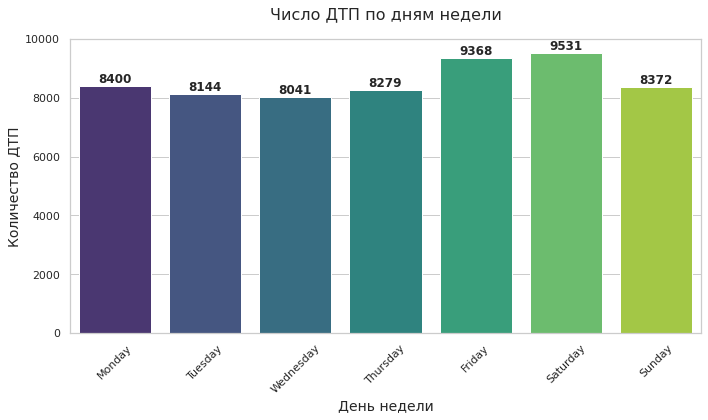

In [30]:
sns.set(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12

if 'day_of_week' not in result_dtp_df.columns:
    result_dtp_df['day_of_week'] = result_dtp_df['properties.datetime'].dt.day_name()

days_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
accidents_by_day = (
    result_dtp_df
    .groupby('day_of_week')
    .size()
    .reindex(days_order, fill_value=0)
)

plt.figure(figsize=(10, 6))
ax = sns.barplot(x=accidents_by_day.index, y=accidents_by_day.values, palette='viridis')

plt.title('Число ДТП по дням недели', fontsize=16, pad=20)
plt.xlabel('День недели', fontsize=14)
plt.ylabel('Количество ДТП', fontsize=14)
plt.xticks(rotation=45)

for i, p in enumerate(ax.patches):
    height = p.get_height()
    
    ax.text(
        p.get_x() + p.get_width() / 2.,  
        height,                         
        f'{int(height)}',                
        ha='center', 
        va='bottom', 
        fontsize=12,
        fontweight='bold'
    )

plt.tight_layout()
plt.show()

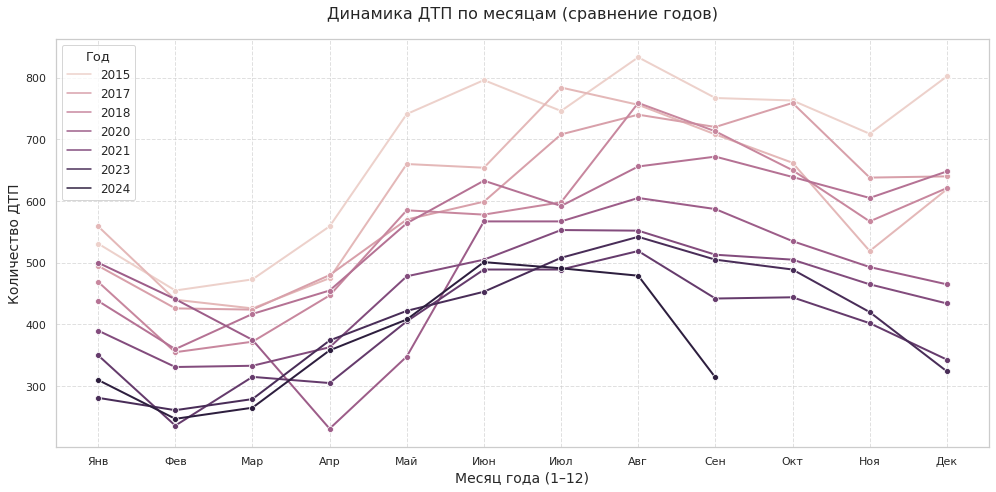

In [31]:
sns.set(style="whitegrid")
plt.rcParams['figure.figsize'] = (14, 7)
plt.rcParams['font.size'] = 12

date_col = result_dtp_df['properties.datetime'] 

result_dtp_df['year'] = date_col.dt.year
result_dtp_df['month'] = date_col.dt.month

monthly_stats = result_dtp_df.groupby(['year', 'month']).size().reset_index(name='count')

plt.figure(figsize=(14, 7))

sns.lineplot(
    data=monthly_stats,
    x='month',               
    y='count',               
    hue='year',             
    marker='o',
    linewidth=2,
    markersize=6
)

plt.title('Динамика ДТП по месяцам (сравнение годов)', fontsize=16, pad=20)
plt.xlabel('Месяц года (1–12)', fontsize=14)
plt.ylabel('Количество ДТП', fontsize=14)

plt.xticks(ticks=range(1, 13), labels=['Янв', 'Фев', 'Мар', 'Апр', 'Май', 'Июн', 
                                       'Июл', 'Авг', 'Сен', 'Окт', 'Ноя', 'Дек'])

plt.legend(title='Год', title_fontsize='13', fontsize='12')
plt.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

Анализ временных рядов показал наличие выраженной недельной цикличности: наибольшее число ДТП фиксируется в конце рабочей недели (пятница: 9 368 ДТП) и в выходные дни (суббота: 9 531 ДТП). Это может быть связано с ростом интенсивности движения, усталостью водителей и изменением поведенческих паттернов в выходные.
В месячной динамике наблюдается сезонная волатильность без явного долгосрочного тренда на рост или снижение общего числа аварий.

### Категории водителей по стажу. Встречаются ли категории, которые разительно отличаются по числу ДТП

In [32]:
unique_roles = result_participiants_df['role'].unique()
print(unique_roles)

['Водитель' 'Пассажир' 'Велосипедист' 'Пешеход'
 'Пешеход, перед ДТП находившийся в (на) ТС в качестве водителя или пешеход, перед ДТП находившийся в (на) ТС в качестве пассажира']


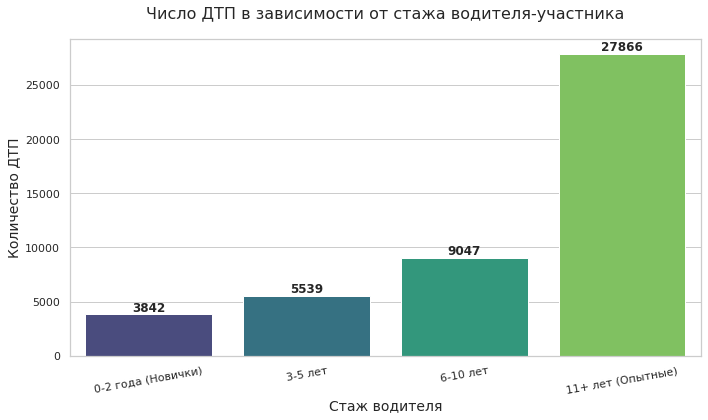

На основе анализа выявлено:
- В категории '0-2 года (Новички)' произошло 3842 ДТП.
- В категории '3-5 лет' произошло 5539 ДТП.
- В категории '6-10 лет' произошло 9047 ДТП.
- В категории '11+ лет (Опытные)' произошло 27866 ДТП.


In [33]:
sns.set(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12

df = result_participiants_df.copy()

df['years_of_driving_experience'] = pd.to_numeric(df['years_of_driving_experience'], errors='coerce')

valid_roles = ['Водитель']
drivers_only = df[df['role'].isin(valid_roles)].copy()
drivers_only = drivers_only.dropna(subset=['years_of_driving_experience'])

max_exp = drivers_only['years_of_driving_experience'].max()
bin_edges = [0, 2, 5, 10, max_exp + 1]
labels = ['0-2 года (Новички)', '3-5 лет', '6-10 лет', '11+ лет (Опытные)']

drivers_only['experience_group'] = pd.cut(
    drivers_only['years_of_driving_experience'], 
    bins=bin_edges, 
    labels=labels, 
    right=True, 
    include_lowest=True
)

accident_categories = drivers_only.groupby('id')['experience_group'].apply(lambda x: list(x.unique())).reset_index()
exploded = accident_categories.explode('experience_group')
stats_by_accident = exploded.groupby('experience_group')['id'].nunique().reset_index(name='count_accidents')

category_order = ['0-2 года (Новички)', '3-5 лет', '6-10 лет', '11+ лет (Опытные)']

stats_by_accident = stats_by_accident.assign(
    experience_group=pd.Categorical(stats_by_accident['experience_group'], categories=category_order, ordered=True)
).sort_values('experience_group').reset_index(drop=True)

plt.figure(figsize=(10, 6))

ax = sns.barplot(
    data=stats_by_accident, 
    x='experience_group', 
    y='count_accidents', 
    palette='viridis'
)

plt.title('Число ДТП в зависимости от стажа водителя-участника', fontsize=16, pad=20)
plt.xlabel('Стаж водителя', fontsize=14)
plt.ylabel('Количество ДТП', fontsize=14)
plt.xticks(rotation=10)

for p in ax.patches:
    height = p.get_height()
    ax.text(
        p.get_x() + p.get_width() / 2., 
        height, 
        f'{int(height)}', 
        ha='center', 
        va='bottom', 
        fontsize=12,
        fontweight='bold'
    )

plt.tight_layout()
plt.show()

print("На основе анализа выявлено:")
for _, row in stats_by_accident.iterrows():
    print(f"- В категории '{row['experience_group']}' произошло {row['count_accidents']} ДТП.")

Анализ распределения ДТП по стажу водителей показал, что наибольшее абсолютное количество аварий (27 866) приходится на водителей со стажем более 11 лет. Однако это обусловлено численным преобладанием данной категории среди всех участников дорожного движения. > > Критически важным показателем является высокая аварийность среди новичков (0–2 года): несмотря на малую долю в общем потоке транспорта, они участвуют в значительном числе ДТП (3 842 случая), что подтверждает гипотезу о повышенном риске в первые годы вождения.

### Как менялось число аварий в Кировской (Киров входит в численность) и Московской области (Москва исключена). Где аварий больше в относительном выражении — в пересчёте на 100 тысяч жителей

In [34]:
unique_areas = result_dtp_df['properties.parent_region'].unique()
print(unique_areas)

['Кировская область' 'Московская область']


Отфильтровано записей для анализа: 60135
Московская область    45618
Кировская область     14517
Name: flat_parent_region, dtype: int64
Для некоторых годов не найдено данных о населении.
    flat_parent_region  year  accidents_count  population
0    Кировская область  2015             1532         NaN
1    Кировская область  2016             1468         NaN
2    Кировская область  2017             1452         NaN
9    Кировская область  2024              991         NaN
10  Московская область  2015             6643         NaN
11  Московская область  2016             5794         NaN
12  Московская область  2017             5747         NaN
19  Московская область  2024             2382         NaN

Статистика аварий на 100 тыс. жителей:
    flat_parent_region  year  accidents_count  population  accidents_per_100k
3    Кировская область  2018             1612   1291684.0              124.80
4    Кировская область  2019             1568   1283238.0              122.19
5    Кировская об

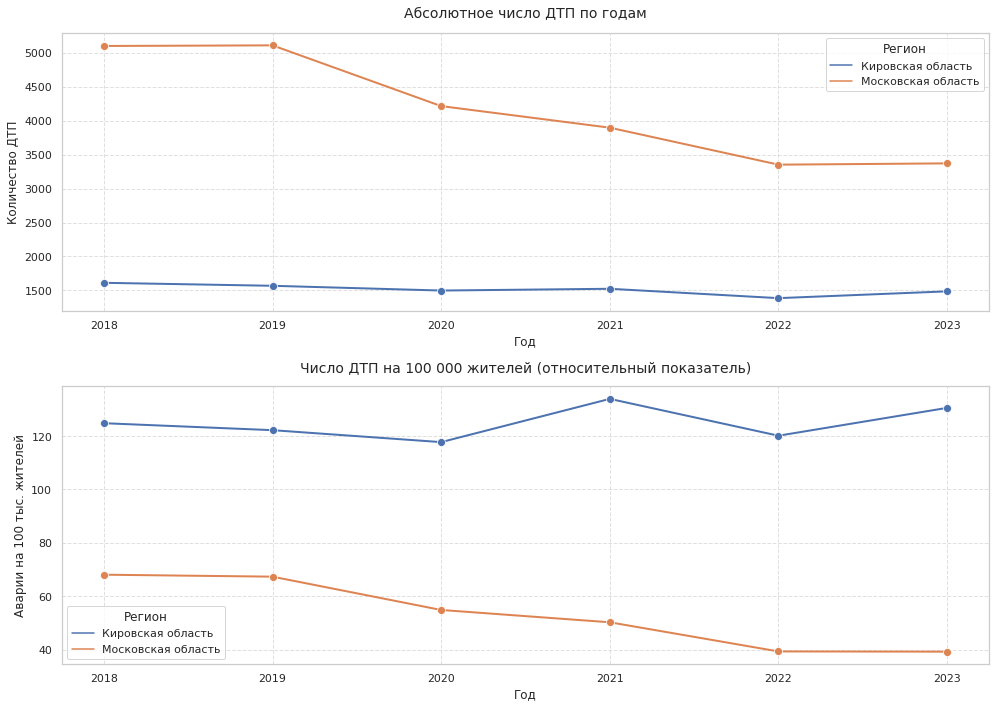

Пик аварийности зафиксирован в 2021 году в Кировская область: 133.90 аварий на 100 тыс. жителей.

Средняя аварийность за период:
- Кировская область: 124.88 аварий на 100 тыс. жителей
- Московская область: 53.23 аварий на 100 тыс. жителей

 ВЫВОД: В относительном выражении аварийность выше в Кировской области.


In [35]:
sns.set(style="whitegrid") 
plt.rcParams['figure.figsize'] = (12, 7) 
plt.rcParams['font.size'] = 12

data = result_dtp_df.copy()

if data['properties.datetime'].dtype == 'object':
    temp_dt = pd.to_datetime(data['properties.datetime'], errors='coerce')
    data['year'] = temp_dt.dt.year
    data = data.dropna(subset=['year'])
else:
    data['year'] = data['properties.datetime'].dt.year

data['flat_parent_region'] = data['properties.parent_region']

regions_to_analyze = ['Кировская область', 'Московская область']
df_filtered = data[data['flat_parent_region'].isin(regions_to_analyze)].copy()

print(f"Отфильтровано записей для анализа: {len(df_filtered)}")
print(df_filtered['flat_parent_region'].value_counts())

accidents_by_year = df_filtered.groupby(['flat_parent_region', 'year']).size().reset_index(name='accidents_count')

population_data = {
    'Кировская область': {
        2018: 1291684,
        2019: 1283238,
        2020: 1272533,
        2021: 1138168,
        2022: 1153873,
        2023: 1138412
    },
    'Московская область': {
        2018: 7490803,
        2019: 7586395,
        2020: 7678125,
        2021: 7749464,
        2022: 8512029,
        2023: 8578638
    }
}

def get_population(row):
    region = row['flat_parent_region']
    year = int(row['year'])
    return population_data.get(region, {}).get(year, None)

accidents_by_year['population'] = accidents_by_year.apply(get_population, axis=1)

if accidents_by_year['population'].isnull().any():
    print("Для некоторых годов не найдено данных о населении.")
    print(accidents_by_year[accidents_by_year['population'].isnull()])

accidents_by_year = accidents_by_year.dropna(subset=['population'])

accidents_by_year['accidents_per_100k'] = (accidents_by_year['accidents_count'] / accidents_by_year['population']) * 100000

print("\nСтатистика аварий на 100 тыс. жителей:")
print(accidents_by_year[['flat_parent_region', 'year', 'accidents_count', 'population', 'accidents_per_100k']].round(2))

plt.figure(figsize=(14, 10))

plt.subplot(2, 1, 1)
sns.lineplot(
    data=accidents_by_year,
    x='year',
    y='accidents_count',
    hue='flat_parent_region',
    marker='o',
    linewidth=2,
    markersize=8
)
plt.title('Абсолютное число ДТП по годам', fontsize=14, pad=15)
plt.xlabel('Год')
plt.ylabel('Количество ДТП')
plt.legend(title='Регион')
plt.grid(True, linestyle='--', alpha=0.6)

plt.subplot(2, 1, 2)
sns.lineplot(
    data=accidents_by_year,
    x='year',
    y='accidents_per_100k',
    hue='flat_parent_region',
    marker='o',
    linewidth=2,
    markersize=8
)
plt.title('Число ДТП на 100 000 жителей (относительный показатель)', fontsize=14, pad=15)
plt.xlabel('Год')
plt.ylabel('Аварии на 100 тыс. жителей')
plt.legend(title='Регион')
plt.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

max_row = accidents_by_year.loc[accidents_by_year['accidents_per_100k'].idxmax()]
print(f"Пик аварийности зафиксирован в {int(max_row['year'])} году в {max_row['flat_parent_region']}: "
      f"{max_row['accidents_per_100k']:.2f} аварий на 100 тыс. жителей.")

avg_k = accidents_by_year[accidents_by_year['flat_parent_region'] == 'Кировская область']['accidents_per_100k'].mean()
avg_m = accidents_by_year[accidents_by_year['flat_parent_region'] == 'Московская область']['accidents_per_100k'].mean()

print(f"\nСредняя аварийность за период:")
print(f"- Кировская область: {avg_k:.2f} аварий на 100 тыс. жителей")
print(f"- Московская область: {avg_m:.2f} аварий на 100 тыс. жителей")

if avg_k > avg_m:
    print("\n ВЫВОД: В относительном выражении аварийность выше в Кировской области.")
else:
    print("\n ВЫВОД: В относительном выражении аварийность выше в Московской области.")


# Итоговые выводы


В ходе выполнения кейса «Карта ДТП» был проведён комплексный анализ данных по Кировской и Московской областям. Работа состояла из трёх ключевых этапов: предобработка данных, поиск закономерностей и формирование рекомендаций.
1. Предобработка и очистка данных: были проверены и очищены три основных датасета: ДТП, участники ДТП и транспортные средства. 
* Дубликаты: Выявлено и удалено более 46 000 строк-дубликатов (включая полные копии и неявные дубли по ключевым полям). Это позволило избежать искажения статистики. 
* Пропуски: Проанализированы доли пропущенных значений. Критичных пропусков, влияющих на основные метрики, не обнаружено. Пропуски в поле «стаж водителя» (39,4%) учтены при анализе — выводы по стажу сделаны на подвыборке с соответствующей оговоркой. 
* Типы данных: Приведены к корректному виду даты.

2. Анализ временных и пространственных закономерностей.
* Динамика по дням недели: выявлен чёткий пик аварийности в конце рабочей недели и в выходные. Наибольшее число ДТП приходится на пятницу (9 368) и субботу (9 531). Это связано с усталостью водителей, ростом трафика и изменением поведенческих паттернов. 
* Динамика по месяцам: Наблюдается сезонная волатильность числа ДТП без выраженного линейного тренда на рост или снижение общего количества аварий за 10 лет.

3. Анализ влияния человеческого фактора (стаж водителя).
Анализ показал парадоксальную на первый взгляд картину: абсолютное большинство ДТП (27 866 из 46 300) произошло с участием водителей со стажем более 11 лет. Однако это объясняется не низкой квалификацией опытных водителей, а их численным преобладанием в общем потоке транспорта. Ключевым инсайдом стало выявление высокого риска среди водителей-новичков (стаж 0–2 года): несмотря на малую долю в общем числе водителей, они участвуют в значительном количестве аварий (3 842 случая). Это подтверждает гипотезу о повышенной аварийности в первые годы вождения.

4. Рекомендации заказчику На основе полученных данных рекомендуется: 
1. Сместить фокус профилактики на новичков: усилить контроль ГИБДД за водителями со стажем до 2 лет и запустить целевые информационные кампании об их типичных ошибках. 
2. Оптимизировать патрулирование: увеличить плотность нарядов ДПС в пятницу и субботу, когда фиксируется пик аварийности. 
3. Учитывать относительные показатели: для дальнейшего мониторинга использовать не только абсолютное число ДТП, но и относительные метрики (например, число аварий на 1 000 водителей в каждой категории стажа), чтобы точнее оценивать реальный уровень риска.

Проведённый анализ позволил очистить данные от ошибок, выявить ключевые паттерны аварийности и сформировать практические рекомендации для повышения безопасности дорожного движения.